In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os, sys

from sklearn.model_selection import train_test_split
sys.path.append('../../Share/')
import Model

from collections import Counter

def balance_data(X, y):
    # Count samples per class
    class_counts = Counter(y)
    min_count = min(class_counts.values())  # target: balance all to minority count

    indices_list = []

    for label in sorted(class_counts.keys()):
        label_indices = np.where(y == label)[0]
        selected_indices = np.random.choice(label_indices, size=min_count, replace=False)
        indices_list.extend(selected_indices)

    # Shuffle all selected indices
    balanced_indices = np.random.permutation(indices_list)

    # Subset the data
    X_balanced = X[balanced_indices]
    y_balanced = y[balanced_indices]

    return X_balanced, y_balanced

def random_downsample_Num(X, y=None, n_keep=None, random_state=42):
    np.random.seed(random_state)
    n_samples = X.shape[0]

    if n_keep is None or n_keep > n_samples:
        raise ValueError(f"n_keep must be between 1 and {n_samples}, got {n_keep}")

    idx_keep = np.random.choice(n_samples, size=n_keep, replace=False)
    X_down = X[idx_keep]

    if y is not None:
        y_down = y[idx_keep]
        return X_down, y_down
    else:
        return X_down

# Baseline training on subjects
def feature_analysis(X_lst, y_lst):
    num_trials = len(X_lst)
    all_acc = []
    for t in range(num_trials):
        X, y = X_lst[t].reshape(-1,16,14,1), y_lst[t]
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)
        feature_set = 14
        feat_acc = []

        for f in range(feature_set):
            X_train_f = X_train[:,:,f,:]
            X_test_f = X_test[:,:,f,:]
            #model = Model.Original_model(input_shape=X_train.shape[1:], num_class=6)
            model = Model.Original_model_1DCNN(input_size=X_train_f.shape[1:], num_class=6)

            history, _ = Model.Train_model(model, X_train_f, y_train, X_test_f, y_test, set_epoch=50, set_batch_size=128, Model_name=None, set_verbose=False, save_model_set=False)
            #plt.plot(history.history['val_accuracy'])
            #plt.plot(history.history['accuracy'])
            #plt.show()

            print(f"\tTrial {t+1}/{num_trials}/feat{f} | Val Acc: {np.max(history.history['val_accuracy'])}")
            feat_acc.append(np.max(history.history['val_accuracy']))
        all_acc.append(feat_acc)

    return all_acc


def baseline_run(X_lst, y_lst):
    num_trials, all_acc_per_session = len(X_lst), []
    feature_set, num_channels = 14, 16

    for t in range(num_trials):
        X, y = X_lst[t].reshape(-1,num_channels,feature_set,1), y_lst[t]
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=42)

        model = Model.Original_model(input_shape=X_train.shape[1:], num_class=6)
        history, _ = Model.Train_model(model, X_train, y_train, X_test, y_test, set_epoch=100, set_batch_size=128, Model_name=None, set_verbose=False, save_model_set=False)

        print(f"\tTrial {t+1}/{num_trials} | Val Acc: {np.max(history.history['val_accuracy'])}")
        all_acc_per_session.append(np.max(history.history['val_accuracy']))

    return all_acc_per_session


def baseline_run_specific_T(X_lst, y_lst, trials):
    all_acc_per_session = []
    feature_set, num_channels = 14, 16

    for t in trials:
        X, y = X_lst[t].reshape(-1,num_channels,feature_set,1), y_lst[t]
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

        model = Model.Original_model(input_shape=X_train.shape[1:], num_class=6)
        history, _ = Model.Train_model(model, X_train, y_train, X_test, y_test, set_epoch=100, set_batch_size=128, Model_name=None, set_verbose=False, save_model_set=False)

        print(f"\tTrial {t+1}/ | Val Acc: {np.max(history.history['val_accuracy'])}")
        all_acc_per_session.append(np.max(history.history['val_accuracy']))

    return all_acc_per_session


def baseline_run_specific_T_with_one_feature(X_lst, y_lst, trials, f=2):
    all_acc_per_session = []
    feature_set, num_channels = 14, 16

    for t in trials:
        X, y = X_lst[t].reshape(-1,num_channels,feature_set,1), y_lst[t]
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)
        X_train, X_test = X_train[:,:,f,:], X_test[:,:,f,:]

        model = Model.Original_model_1DCNN(input_size=X_train.shape[1:], num_class=6)
        history, _ = Model.Train_model(model, X_train, y_train, X_test, y_test, set_epoch=50, set_batch_size=128, Model_name=None, set_verbose=False, save_model_set=False)

        print(f"\tTrial {t+1}/ | Val Acc: {np.max(history.history['val_accuracy'])}")
        all_acc_per_session.append(np.max(history.history['val_accuracy']))

    return all_acc_per_session


def inter_session_run(X_lst, y_lst):
    num_trials = len(X_lst)
    all_acc_K = []

    for t in range(1,num_trials-1):
        X_train, y_train = [X_lst[i].reshape(-1, 16, 14, 1) for i in range(t)], [y_lst[i] for i in range(t)]
        X_train = np.concatenate(X_train, axis=0)
        y_train = np.concatenate(y_train, axis=0)

        X_test, y_test = X_lst[t+1].reshape(-1, 16, 14, 1), y_lst[t+1]

        #X_test, y_test = random_downsample_Num(X_test, y_test, n_keep=1000, random_state=42)
        print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

        model = Model.Original_model(input_shape=X_train.shape[1:], num_class=6)
        history, _ = Model.Train_model(model, X_train, y_train, X_test, y_test, set_epoch=100, set_batch_size=128, Model_name=None, set_verbose=False, save_model_set=False)

        print(f"\tTrial {t+1}/{num_trials} | Val Acc: {np.max(history.history['val_accuracy'])}")
        all_acc_K.append(np.max(history.history['val_accuracy']))
    return all_acc_K

def inter_session_run_one_feature(X_lst, y_lst, f=2):
    num_trials = len(X_lst)
    all_acc_K = []

    for t in [1, 4, 7, 9]:
        X_train = [X_lst[i].reshape(-1, 16, 14, 1) for i in range(t)]
        X_train = np.concatenate(X_train, axis=0)
        y_train = [y_lst[i] for i in range(t)]
        y_train = np.concatenate(y_train, axis=0)

        X_test = [X_lst[i].reshape(-1, 16, 14, 1) for i in range(t, len(X_lst))]
        X_test = np.concatenate(X_test, axis=0)

        y_test = [y_lst[i] for i in range(t, len(y_lst))]
        y_test = np.concatenate(y_test, axis=0)
        X_test, y_test = random_downsample_Num(X_test, y_test, n_keep=1000, random_state=42)
        X_train, X_test = X_train[:,:,f,:], X_test[:,:,f,:]
        print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

        model = Model.Original_model_1DCNN(input_size=X_train.shape[1:], num_class=6)
        history, _ = Model.Train_model(model, X_train, y_train, X_test, y_test, set_epoch=50, set_batch_size=128, Model_name=None, set_verbose=False, save_model_set=False)

        print(f"\tTrial {t+1}/{num_trials}/feat{f} | Val Acc: {np.max(history.history['val_accuracy'])}")
        all_acc_K.append(np.max(history.history['val_accuracy']))
    return all_acc_K


### Subject 1 버리기 + use only subject 2 and 3

In [2]:
path = 'C:/Users/hml76/Desktop/Jupyter/Federated Prototype Learning/Dataset/Ours_cleaned/'
fname = os.listdir(path)

subjects = {
    "subject1": {"X": [], "Y": []},
    "subject2": {"X": [], "Y": []},
    "subject3": {"X": [], "Y": []},
}

for f in fname:
    for i in range(10):
        X = np.array(pd.read_csv(path + f'{f}/rep{i}_X.csv'))
        y = np.array(pd.read_csv(path + f'{f}/rep{i}_Y.csv'))

        # shuffle
        #indices = np.random.permutation(len(X))
        #X, y = X[indices], y[indices]

        # convert one-hot to integer labels
        y_int = np.argmax(y, axis=1)
        num_classes = np.max(y_int) + 1
        X, y_int = balance_data(X, y_int)

        # example rule to assign data to subject dict
        if "subject1" in f:
            subjects["subject1"]["X"].append(X)
            subjects["subject1"]["Y"].append(y_int)
        elif "subject2" in f:
            subjects["subject2"]["X"].append(X)
            subjects["subject2"]["Y"].append(y_int)
        elif "subject3" in f:
            subjects["subject3"]["X"].append(X)
            subjects["subject3"]["Y"].append(y_int)

X_lst2, y_lst2 = subjects["subject2"]["X"], subjects["subject2"]["Y"]
X_lst3, y_lst3 = subjects["subject3"]["X"], subjects["subject3"]["Y"]

1. K1/4/7/10 initialization (저걸로 학습시키기) + Test on rest of the subjects
2.

# Baseline - S2, S3

In [4]:
S2_baseline = baseline_run(X_lst2, y_lst2)
S3_baseline = baseline_run(X_lst3, y_lst3)

Start Training (total epochs: 100)...
Maximum training accuracy : 61.79%
Maximum validation accuracy : 57.69%
	Trial 1/10 | Val Acc: 0.5769491791725159
Start Training (total epochs: 100)...
Maximum training accuracy : 52.4%
Maximum validation accuracy : 62.72%
	Trial 2/10 | Val Acc: 0.6271721720695496
Start Training (total epochs: 100)...
Maximum training accuracy : 78.79%
Maximum validation accuracy : 80.19%
	Trial 3/10 | Val Acc: 0.8019323945045471
Start Training (total epochs: 100)...
Maximum training accuracy : 66.52%
Maximum validation accuracy : 67.54%
	Trial 4/10 | Val Acc: 0.6753846406936646
Start Training (total epochs: 100)...
Maximum training accuracy : 81.87%
Maximum validation accuracy : 83.89%
	Trial 5/10 | Val Acc: 0.8388829231262207
Start Training (total epochs: 100)...
Maximum training accuracy : 17.75%
Maximum validation accuracy : 16.64%
	Trial 6/10 | Val Acc: 0.16635338962078094
Start Training (total epochs: 100)...
Maximum training accuracy : 18.49%
Maximum validat

In [ ]:
#S2_baseline_Ts = baseline_run_specific_T(X_lst2, y_lst2, [1,4,7,9])
#S3_baseline_Ts = baseline_run_specific_T(X_lst3, y_lst3, [1,4,7,9])

#S2_baseline_Ts_f = baseline_run_specific_T_with_one_feature(X_lst2, y_lst2, [1,4,7], f=2)
#S3_baseline_Ts_f = baseline_run_specific_T_with_one_feature(X_lst3, y_lst3, [1,4,7], f=2)

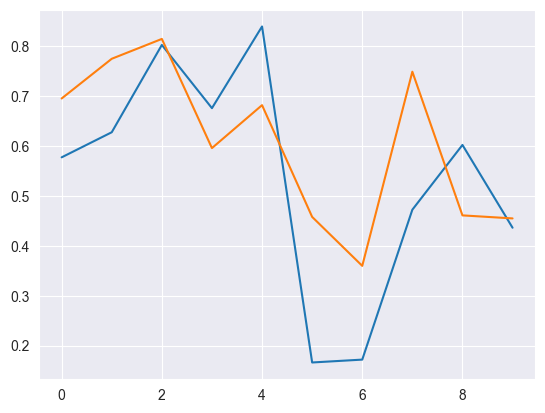

In [7]:
plt.plot(S2_baseline)
plt.plot(S3_baseline)
plt.show()

In [9]:
S2_baseline_clean = [float(x) for x in S2_baseline]
S3_baseline_clean = [float(x) for x in S3_baseline]

# Inter-session

In [20]:
inter_session_K_S2 = inter_session_run(X_lst2, y_lst2)
inter_session_K_S3 = inter_session_run(X_lst3, y_lst3)

(4914, 16, 14, 1) (4914,) (6210, 16, 14, 1) (6210,)
Start Training (total epochs: 100)...
Maximum training accuracy : 62.94%
Maximum validation accuracy : 47.31%
	Trial 2/10 | Val Acc: 0.4731079041957855
(11244, 16, 14, 1) (11244,) (4332, 16, 14, 1) (4332,)
Start Training (total epochs: 100)...
Maximum training accuracy : 66.38%
Maximum validation accuracy : 62.6%
	Trial 3/10 | Val Acc: 0.6260387897491455
(17454, 16, 14, 1) (17454,) (6204, 16, 14, 1) (6204,)
Start Training (total epochs: 100)...
Maximum training accuracy : 70.51%
Maximum validation accuracy : 44.6%
	Trial 4/10 | Val Acc: 0.4460025727748871
(21786, 16, 14, 1) (21786,) (7092, 16, 14, 1) (7092,)
Start Training (total epochs: 100)...
Maximum training accuracy : 71.72%
Maximum validation accuracy : 22.39%
	Trial 5/10 | Val Acc: 0.2239142656326294
(27990, 16, 14, 1) (27990,) (6042, 16, 14, 1) (6042,)
Start Training (total epochs: 100)...
Maximum training accuracy : 72.38%
Maximum validation accuracy : 20.69%
	Trial 6/10 | Va

In [22]:
inter_session_K_S2_clean = [float(x) for x in inter_session_K_S2]
inter_session_K_S3_clean = [float(x) for x in inter_session_K_S3]

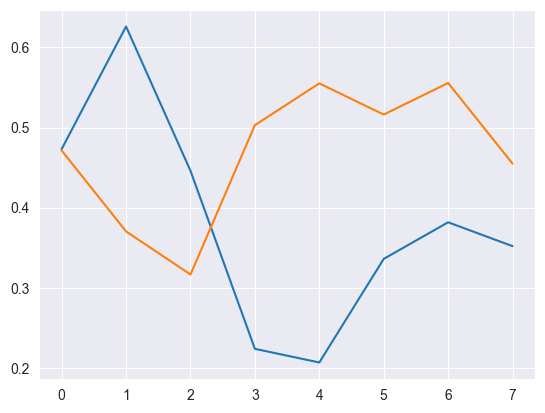

In [23]:
plt.plot(inter_session_K_S2_clean)
plt.plot(inter_session_K_S3_clean)
plt.show()

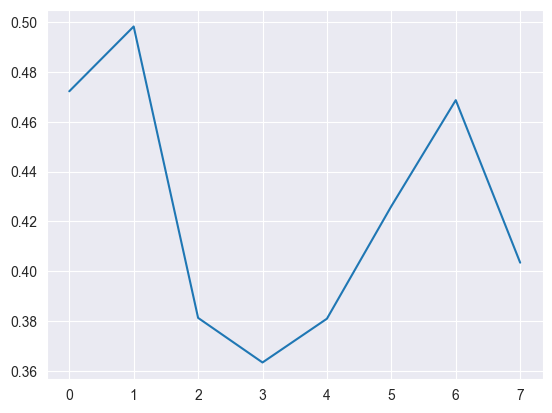

In [24]:
plt.plot(np.mean([inter_session_K_S2_clean, inter_session_K_S3_clean], axis=0))
plt.show()

Conclusion

이건 옛날 데이터라 그런지 성능이 이상함
- 그냥 이건 나중에 iENG vs sENG 용도로만 사용하는게 좋을듯
- Offline / Online 에는 빼자
- 애초에 우리가 tailored 한 실험셋팅도 아니었음